In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

%matplotlib inline

In [2]:
df = pd.read_csv('automobile_sales.csv')

In [3]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


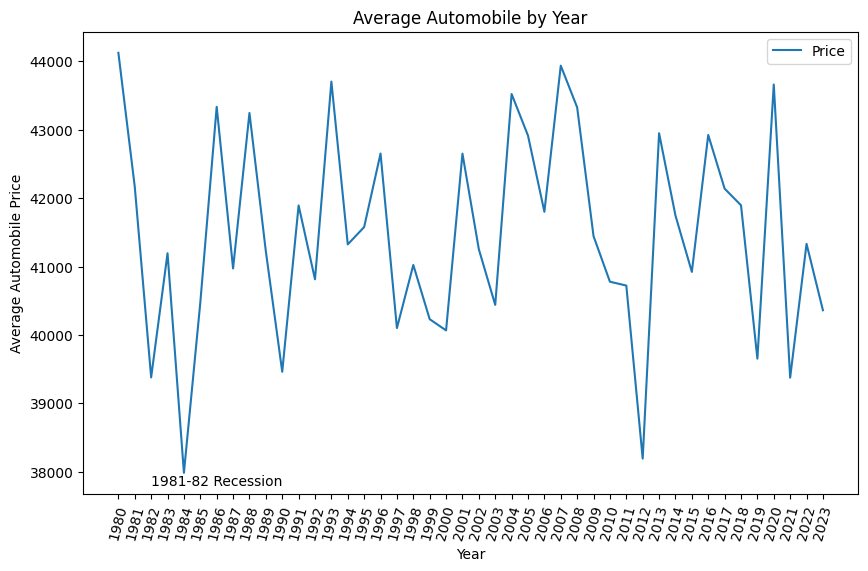

In [33]:
df_year_grouped = df.groupby('Year')['Price'].mean()
plt.figure(figsize=(10, 6))
df_year_grouped.plot(kind='line')
plt.xticks(list(range(1980,2024)), rotation = 75)
plt.xlabel('Year')
plt.ylabel('Average Automobile Price')
plt.title('Average Automobile by Year')
plt.text(1982, 37800, '1981-82 Recession')
plt.legend()
plt.show()

C:\Users\e424324\AppData\Local\Temp\1\ipykernel_33180\3504536024.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


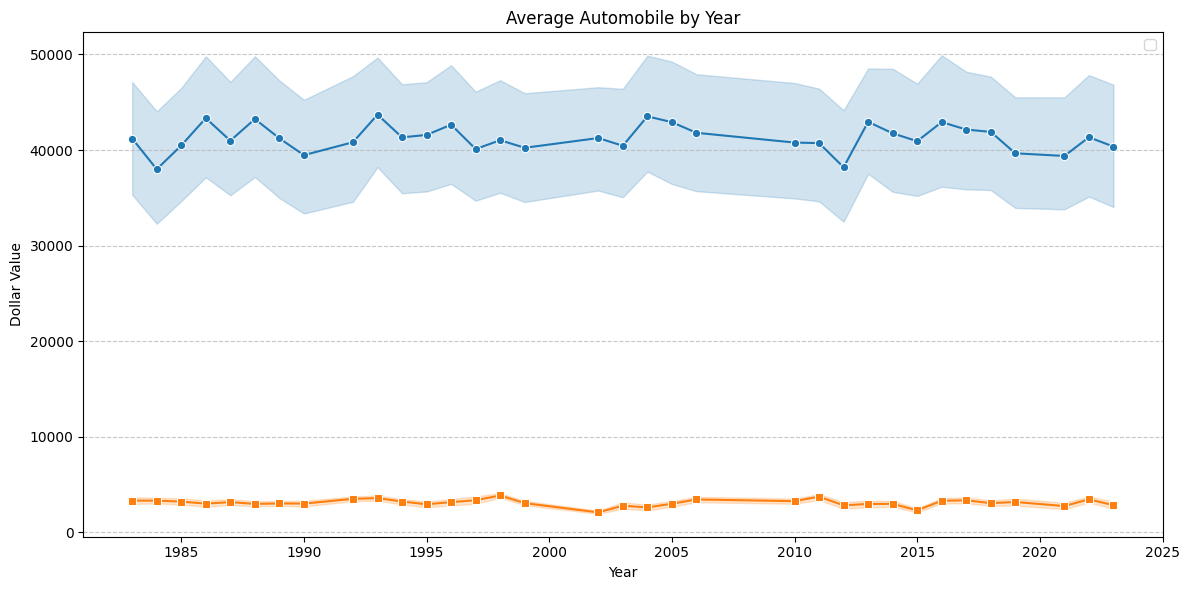

In [35]:
# Assuming 'df' is your dataset
df_non_rec = df[df['Recession'] == 0]

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_trends_non_rec = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Price', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)

df_rec = df[df['Recession'] == 1]

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_trends_rec = df_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Price', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_non_rec, x='Year', y='Price', marker='o')
sns.lineplot(data=df_non_rec, x='Year', y='Advertising_Expenditure', marker='s')

plt.xlabel('Year')
plt.ylabel('Dollar Value')
plt.title('Average Automobile by Year')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend()
plt.tight_layout()
plt.show()

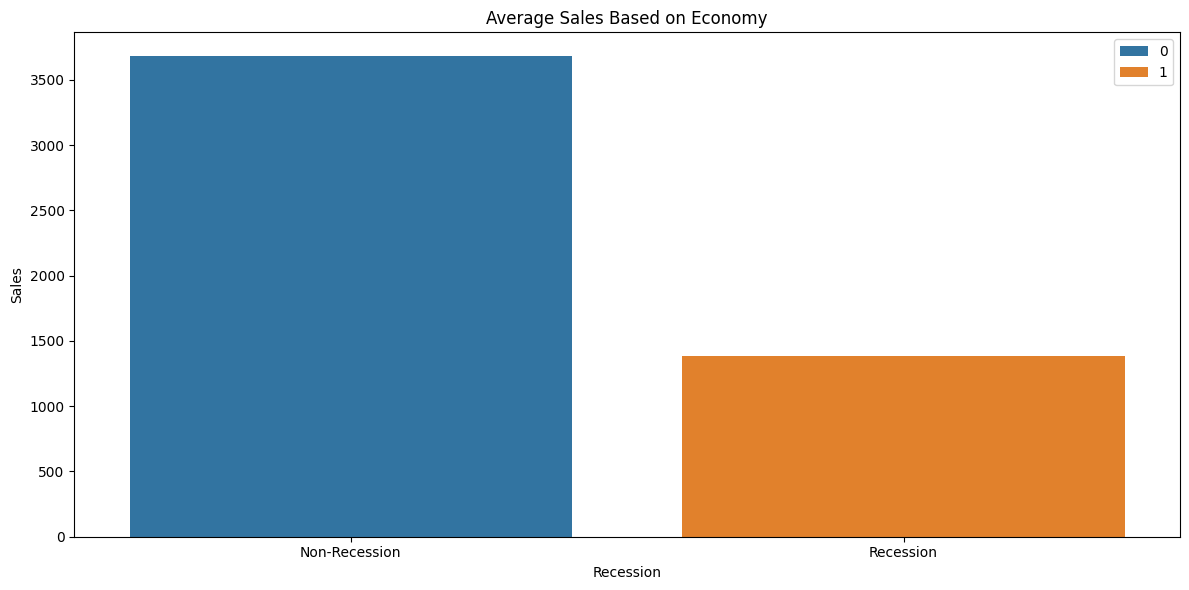

In [36]:

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_rec = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_rec, x='Recession', y='Automobile_Sales', hue='Recession')

plt.xlabel('Recession')
plt.ylabel('Sales')
plt.title('Average Sales Based on Economy')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])

plt.legend()
plt.tight_layout()
plt.show()

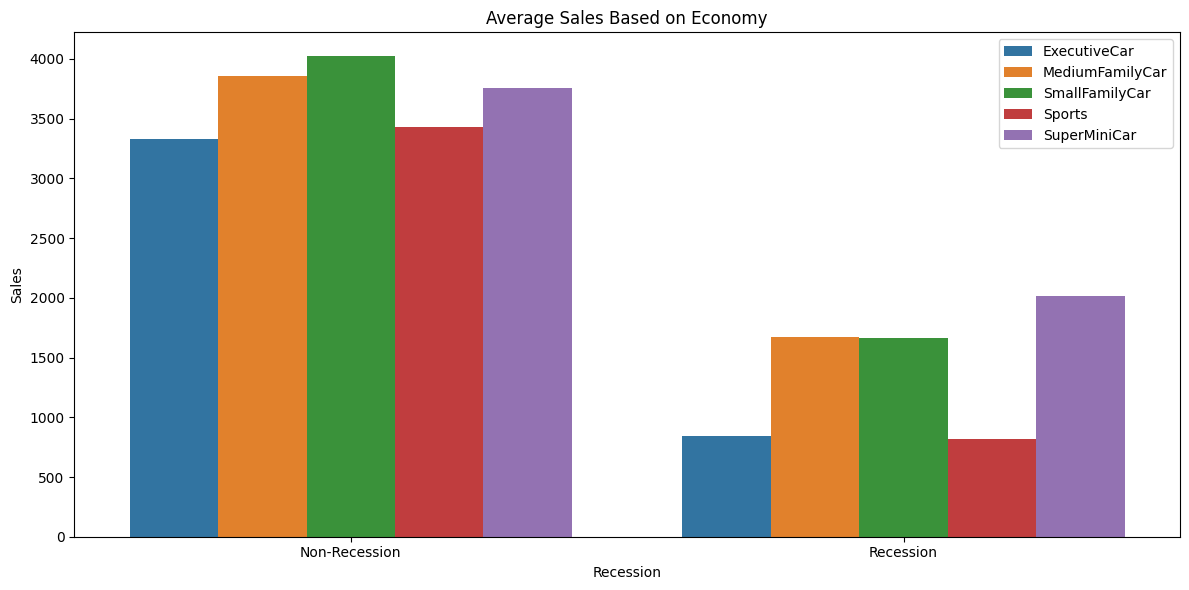

In [39]:

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_rec_type = df.groupby(['Recession', 'Vehicle_Type'], as_index=False)['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_rec_type, x='Recession', y='Automobile_Sales', hue='Vehicle_Type')

plt.xlabel('Recession')
plt.ylabel('Sales')
plt.title('Average Sales Based on Economy')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])

plt.legend()
plt.tight_layout()
plt.show()

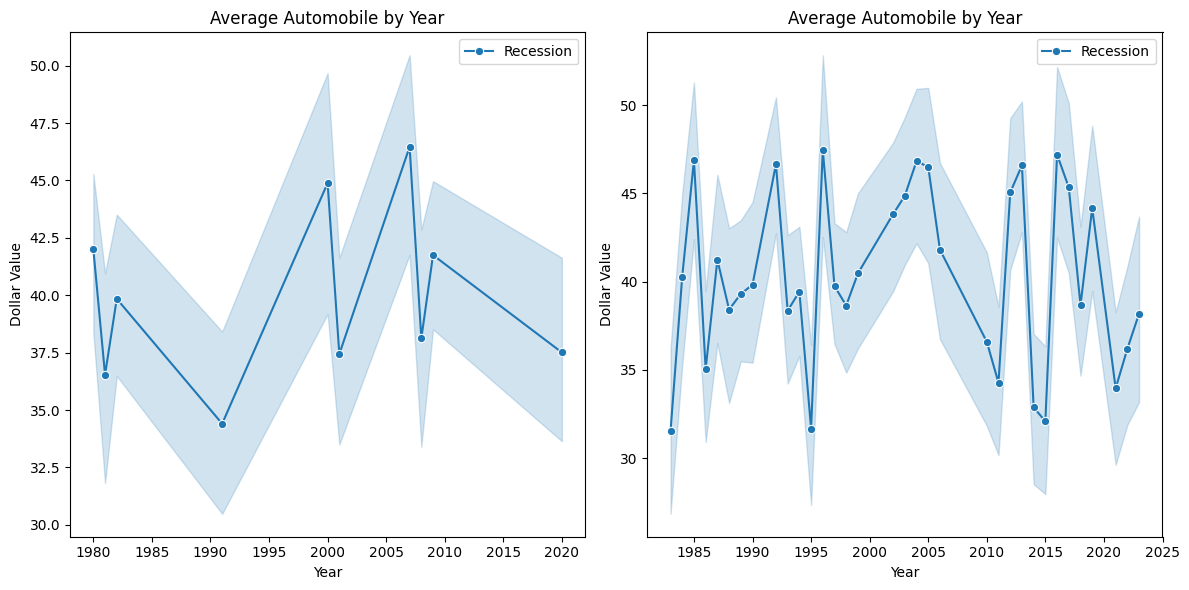

In [40]:
# Assuming 'df' is your dataset
df_non_rec = df[df['Recession'] == 0]

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_trends_non_rec = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Price', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)

df_rec = df[df['Recession'] == 1]

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_trends_rec = df_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Price', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)

fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)

sns.lineplot(data=df_rec, x='Year', y='GDP', marker='o', ax=ax0, label='Recession')

ax0.set_xlabel('Year')
ax0.set_ylabel('Dollar Value')
ax0.set_title('Average Automobile by Year')

sns.lineplot(data=df_non_rec, x='Year', y='GDP', marker='o', ax=ax1, label='Recession')

ax1.set_xlabel('Year')
ax1.set_ylabel('Dollar Value')
ax1.set_title('Average Automobile by Year')

plt.tight_layout()
plt.show()

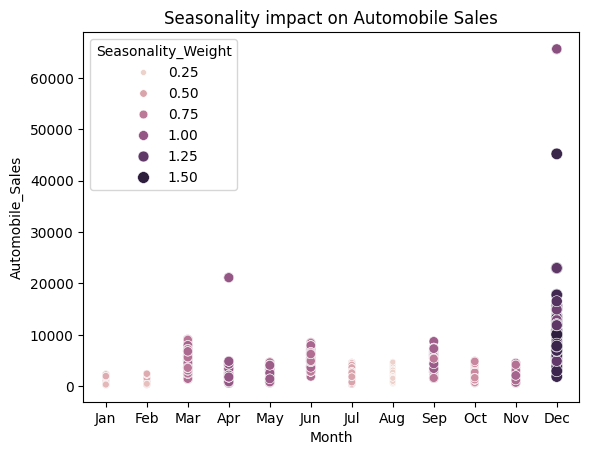

In [42]:
non_rec_data = df[df['Recession'] == 0]

size=non_rec_data['Seasonality_Weight'] #for bubble effect

sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales', size=size, hue='Seasonality_Weight')

#you can further include hue='Seasonality_Weight', legend=False)

plt.xlabel('Month')
plt.ylabel('Automobile_Sales')
plt.title('Seasonality impact on Automobile Sales')

plt.show()

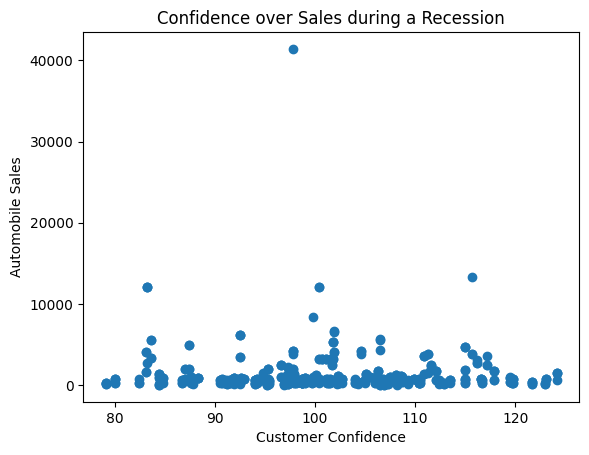

In [43]:
rec_data = df[df['Recession'] == 1]
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'])

plt.xlabel('Customer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Confidence over Sales during a Recession')
plt.show()

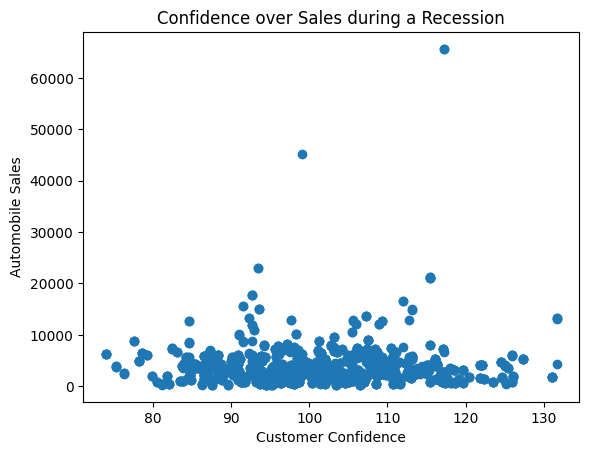

In [44]:
non_rec_data = df[df['Recession'] == 0]
plt.scatter(non_rec_data['Consumer_Confidence'], non_rec_data['Automobile_Sales'])

plt.xlabel('Customer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Confidence over Sales during a Recession')
plt.show()

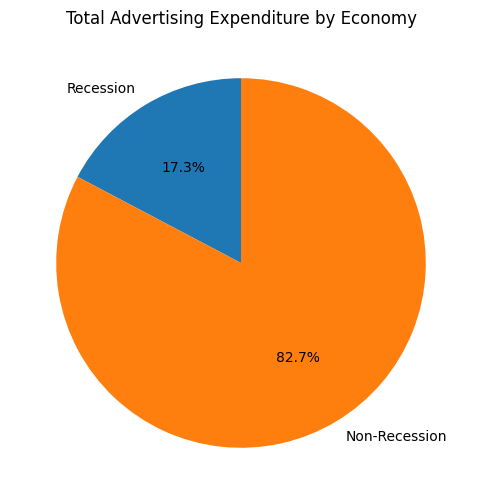

In [45]:
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

# Calculate the total advertising expenditure for both periods
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

# Create a pie chart for the advertising expenditure 
plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Total Advertising Expenditure by Economy')

plt.show()

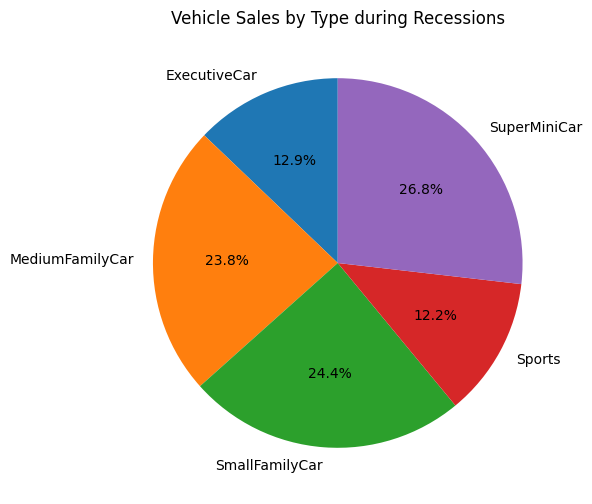

In [ ]:
Rdata = df[df['Recession'] == 1]

# Calculate the sales volume by vehicle type during recessions
VTexpenditure = Rdata.groupby('Vehicle_Type')['Automobile_Sales'].sum()

# Create a pie chart for the share of each vehicle type in total expenditure during recessions
plt.figure(figsize=(12, 6))

labels = VTexpenditure.index
sizes = VTexpenditure.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Vehicle Sales by Type during Recessions')

plt.show()

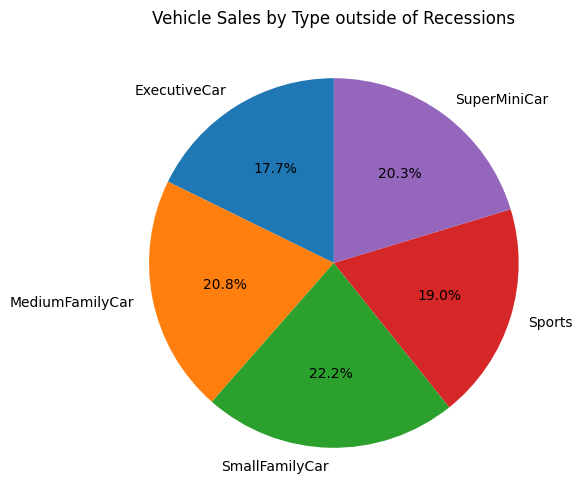

In [47]:
Rdata = df[df['Recession'] == 0]

# Calculate the sales volume by vehicle type during recessions
VTexpenditure = Rdata.groupby('Vehicle_Type')['Automobile_Sales'].sum()

# Create a pie chart for the share of each vehicle type in total expenditure during recessions
plt.figure(figsize=(12, 6))

labels = VTexpenditure.index
sizes = VTexpenditure.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Vehicle Sales by Type outside of Recessions')

plt.show()

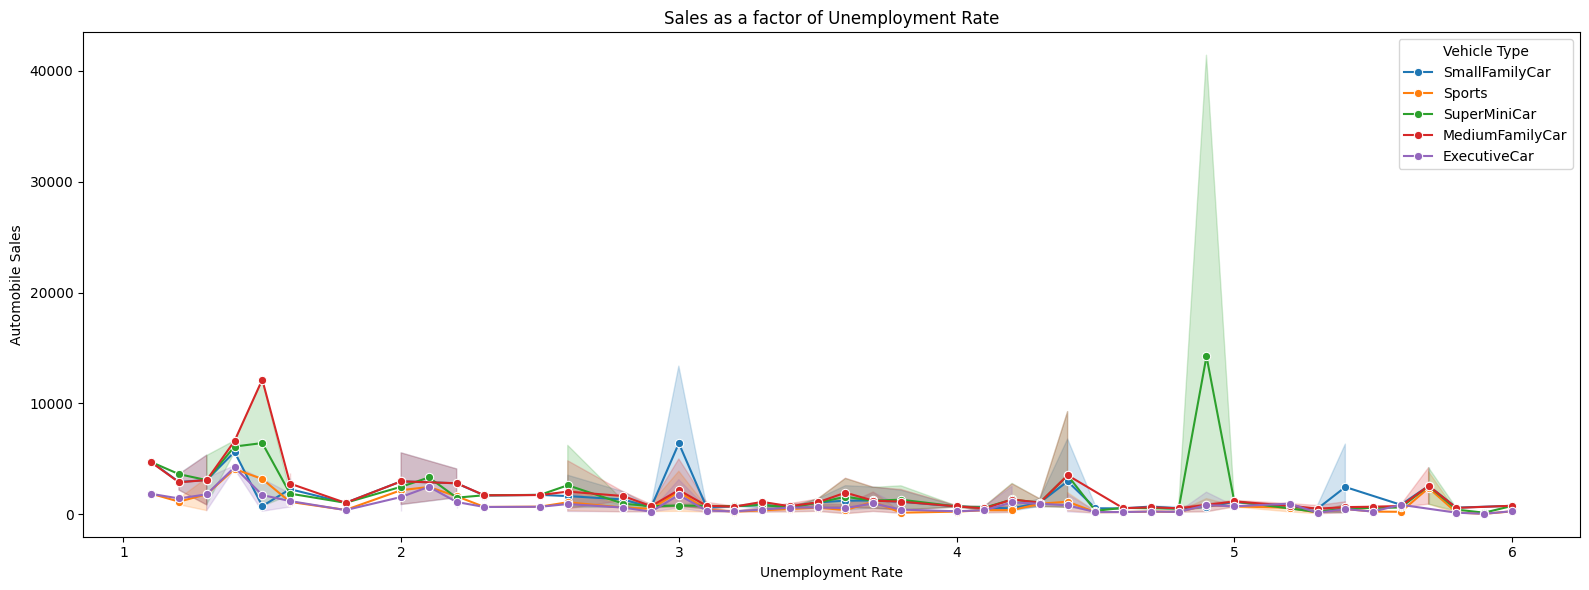

In [49]:
df_rec = df[df['Recession'] == 1]

# Set figure size
plt.figure(figsize=(16, 6))

# Create line plot showing effect of unemployment rate on automobile sales, by vehicle type
sns.lineplot(
    data=df_rec,
    x='unemployment_rate',               # Replace with unemployment rate column (e.g., 'unemployment_rate')
    y='Automobile_Sales',               # Replace with automobile sales column (e.g., 'Automobile_Sales')
    hue='Vehicle_Type',             # Replace with vehicle type column (e.g., 'Vehicle_Type')
    marker='o'
)

# Customize labels, legend, and title
plt.title('Sales as a factor of Unemployment Rate')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')

# Show plot
plt.tight_layout()
plt.show()